In [ ]:
import numpy as np  # numpy 라이브러리 임포트
from dotenv import load_dotenv  # .env 파일에서 환경변수를 불러오는 함수 임포트
from pathlib import Path  # 파일 경로를 다루기 위한 Path 클래스 임포트
import os  # 운영체제와 상호작용을 위한 os 모듈 임포트

# 프로젝트 루트 디렉토리의 .env 파일 경로 설정
ENV_PATH = Path(os.getcwd()).parent.parent.parent.parent / ".env"
load_dotenv(ENV_PATH)  # .env 파일에서 환경변수 불러오기

api_key = os.getenv("GEMINI_API_KEY")  # 환경변수에서 GEMINI_API_KEY 값 가져오기

In [ ]:
from typing import (
    Annotated,  # 변수에 추가적인 메타데이터를 부여할 때 사용
    Sequence,  # 시퀀스(리스트, 튜플 등) 타입 힌트 제공
    TypedDict,  # 딕셔너리의 키와 값 타입을 명시적으로 지정할 때 사용
)

# LangChain의 메시지 베이스 클래스 임포트
from langchain_core.messages import BaseMessage

# 상태에 메시지를 추가하는 헬퍼 함수 임포트
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    """에이전트의 상태를 나타내는 타입 딕트입니다."""

    messages: Annotated[
        Sequence[BaseMessage], add_messages
    ]  # 메시지들의 시퀀스, add_messages로 상태에 추가됨
    number_of_steps: int  # 에이전트가 수행한 단계 수

In [ ]:
from langchain_core.tools import tool  # LangChain에서 tool 데코레이터 임포트
from geopy.geocoders import (
    Nominatim,
)  # 위치(지리정보) 검색을 위한 geopy의 Nominatim 임포트
from pydantic import BaseModel, Field  # 입력 데이터 유효성 검증을 위한 Pydantic 임포트
import requests  # HTTP 요청을 위한 requests 라이브러리 임포트

# Nominatim 지오로케이터 객체 생성 (user_agent는 필수)
geolocator = Nominatim(user_agent="weather-app")


class SearchInput(BaseModel):
    """
    날씨 검색을 위한 입력값 스키마 정의 클래스.
    location: 도시와 주(예: San Francisco)
    date: 예보를 조회할 날짜 (yyyy-mm-dd 형식)
    """

    location: str = Field(description="The city and state, e.g., San Francisco")
    date: str = Field(
        description="the forecasting date for when to get the weather format (yyyy-mm-dd)"
    )


@tool("get_weather_forecast", args_schema=SearchInput, return_direct=True)
def get_weather_forecast(location: str, date: str):
    """
    주어진 위치(도시)와 날짜(yyyy-mm-dd)에 대해 Open-Meteo API를 사용하여 날씨 예보를 조회합니다.
    각 시간별로 온도를 반환하는 딕셔너리를 반환합니다.
    """
    # 입력받은 location(도시명 등)을 위도/경도로 변환
    location = geolocator.geocode(location)
    if location:
        try:
            # Open-Meteo API에 GET 요청을 보내 날씨 데이터 조회
            response = requests.get(
                f"https://api.open-meteo.com/v1/forecast?latitude={location.latitude}&longitude={location.longitude}&hourly=temperature_2m&start_date={date}&end_date={date}"
            )
            data = response.json()  # 응답을 JSON으로 파싱
            # 시간별 온도 정보를 딕셔너리로 반환 (key: 시간, value: 온도)
            return {
                time: temp
                for time, temp in zip(
                    data["hourly"]["time"], data["hourly"]["temperature_2m"]
                )
            }
        except Exception as e:
            # API 요청 또는 데이터 파싱 중 오류 발생 시 에러 메시지 반환
            return {"error": str(e)}
    else:
        # 위치를 찾지 못한 경우 에러 메시지 반환
        return {"error": "Location not found"}


tools = [get_weather_forecast]  # 사용할 툴 리스트에 get_weather_forecast 추가

In [17]:
from datetime import datetime

print(datetime.today().strftime("%Y-%m-%d"))

2025-07-25


In [ ]:
from datetime import datetime  # 현재 날짜를 얻기 위해 datetime 모듈 임포트
from langchain_google_genai import (
    ChatGoogleGenerativeAI,
)  # Google Gemini LLM을 사용하기 위한 클래스 임포트

# LLM(대형 언어 모델) 인스턴스 생성
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-pro",  # 사용할 Gemini 모델 지정
    temperature=1.0,  # 생성 텍스트의 다양성(창의성) 조절 파라미터
    max_retries=2,  # 실패 시 재시도 횟수 설정
    google_api_key=api_key,  # Google API 키 입력 (사전에 정의되어 있어야 함)
)

# get_weather_forecast 툴을 LLM에 바인딩하여, LLM이 해당 툴을 사용할 수 있도록 설정
model = llm.bind_tools([get_weather_forecast])

# 오늘 날짜를 yyyy-mm-dd 형식으로 포맷팅하여, 베를린의 오늘 날씨를 묻는 프롬프트 생성
prompt = f"What is the weather in Berlin on {datetime.today().strftime('%Y-%m-%d')}"

# LLM에 프롬프트를 전달하여, 툴을 활용한 응답을 받아옴
res = model.invoke(prompt)

# 결과 출력
print(res)

content='' additional_kwargs={'function_call': {'name': 'get_weather_forecast', 'arguments': '{"date": "2025-07-25", "location": "Berlin"}'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-pro', 'safety_ratings': []} id='run--cebb7bee-efa9-42cf-8c2f-7d4d4743cefc-0' tool_calls=[{'name': 'get_weather_forecast', 'args': {'date': '2025-07-25', 'location': 'Berlin'}, 'id': '9b8d8f54-da14-4017-9c89-955afb7edad0', 'type': 'tool_call'}] usage_metadata={'input_tokens': 131, 'output_tokens': 253, 'total_tokens': 384, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 222}}


In [19]:
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableConfig

tools_by_name = {tool.name: tool for tool in tools}


# Define our tool node
def call_tool(state: AgentState):
    outputs = []
    # Iterate over the tool calls in the last message
    for tool_call in state["messages"][-1].tool_calls:
        # Get the tool by name
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=tool_result,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}


def call_model(
    state: AgentState,
    config: RunnableConfig,
):
    # Invoke the model with the system prompt and the messages
    response = model.invoke(state["messages"], config)
    # We return a list, because this will get added to the existing messages state using the add_messages reducer
    return {"messages": [response]}


# Define the conditional edge that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    # If the last message is not a tool call, then we finish
    if not messages[-1].tool_calls:
        return "end"
    # default to continue
    return "continue"

In [20]:
from langgraph.graph import StateGraph, END

# Define a new graph with our state
workflow = StateGraph(AgentState)

# 1. Add our nodes
workflow.add_node("llm", call_model)
workflow.add_node("tools", call_tool)
# 2. Set the entrypoint as `agent`, this is the first node called
workflow.set_entry_point("llm")
# 3. Add a conditional edge after the `llm` node is called.
workflow.add_conditional_edges(
    # Edge is used after the `llm` node is called.
    "llm",
    # The function that will determine which node is called next.
    should_continue,
    # Mapping for where to go next, keys are strings from the function return, and the values are other nodes.
    # END is a special node marking that the graph is finish.
    {
        # If `tools`, then we call the tool node.
        "continue": "tools",
        # Otherwise we finish.
        "end": END,
    },
)
# 4. Add a normal edge after `tools` is called, `llm` node is called next.
workflow.add_edge("tools", "llm")

# Now we can compile and visualize our graph
graph = workflow.compile()

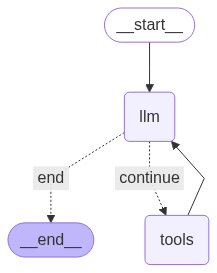

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
from datetime import datetime

# Create our initial message dictionary
inputs = {
    "messages": [
        (
            "user",
            f"What is the weather in Berlin on {datetime.today().strftime('%Y-%m-%d')}?",
        )
    ]
}

# call our graph with streaming to see the steps
for state in graph.stream(inputs, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()

================================ Human Message =================================

What is the weather in Berlin on 2025-07-25?
================================== Ai Message ==================================
Tool Calls:
  get_weather_forecast (e1f11687-030a-4fbd-aa50-a5686cd2f38a)
 Call ID: e1f11687-030a-4fbd-aa50-a5686cd2f38a
  Args:
    location: Berlin
    date: 2025-07-25
================================= Tool Message =================================
Name: get_weather_forecast

{'2025-07-25T00:00': 18.7, '2025-07-25T01:00': 18.8, '2025-07-25T02:00': 18.5, '2025-07-25T03:00': 18.0, '2025-07-25T04:00': 18.3, '2025-07-25T05:00': 18.4, '2025-07-25T06:00': 18.4, '2025-07-25T07:00': 19.0, '2025-07-25T08:00': 20.1, '2025-07-25T09:00': 21.0, '2025-07-25T10:00': 21.4, '2025-07-25T11:00': 21.4, '2025-07-25T12:00': 21.7, '2025-07-25T13:00': 22.2, '2025-07-25T14:00': 22.9, '2025-07-25T15:00': 23.5, '2025-07-25T16:00': 23.5, '2025-07-25T17:00': 22.8, '2025-07-25T18:00': 21.9, '2025-07-25T19:00